In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Correlation of tech reps. by BC.

## ChopTFs

In [45]:
ChopTFs = pd.read_csv("../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities.csv", index_col = 0)
ChopTFs_t30 = ChopTFs[ChopTFs["time"] == 30]
ChopTFs_t30

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,ADseq,dbd_overlap_flag,mu,sigma,z-scored_activity,shifted_activity,shifted_active,z-score_active
262756,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,239.0,239.0,2,30,106.0,102.0,-0.353092,-0.369798,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False,-0.738746,0.390466,0.944893,0.368948,False,False
262757,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,TATCTTCGCTT,CCCTCACCCGATTA,65.0,64.0,2,30,15.0,15.0,-0.636822,-0.630089,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ,False,-0.738746,0.390466,0.278276,0.108657,False,False
262758,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,AATCGTACCGA,TTTGATATCCAAAC,35.0,34.0,2,30,7.0,6.0,-0.698970,-0.753328,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,False,-0.738746,0.390466,-0.037344,-0.014582,False,False
262759,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTGCATAGCTG,TATTGTTCTCTGCT,80.0,78.0,2,30,12.0,11.0,-0.823909,-0.850702,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,False,-0.738746,0.390466,-0.286724,-0.111956,False,False
262760,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCTTGTCTAATTTGGCTTCATTCTATAATACTCATGGT,TTTATAATACC,CATCGAACCTGAAC,178.0,177.0,2,30,28.0,25.0,-0.803262,-0.850033,KNSKRQKSSTYTSQTSSPIGPRDPTVQILSNLASFYNTHG,False,-0.738746,0.390466,-0.285012,-0.111287,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215084,TTTGTTTCTTGTGTCTTCTGGAATAATTTGTATTATATTACTGGTA...,GAAATTTGGTAGAGAAGTTGTTCAGAAGAAGAAATTTGAA,ACACCGTGACC,GCATAACAAAGGAT,24.0,24.0,4,30,3.0,3.0,-0.903090,-0.903090,FVSCVFWNNLYYITGTDIVKCCLYRMQKFGREVVQKKKFE,False,-0.769495,0.349001,-0.382793,-0.133595,False,False
1215085,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,AATACGAGACG,GATGCTTTCTCTAT,38.0,37.0,4,30,19.0,16.0,-0.301030,-0.364082,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,False,-0.769495,0.349001,1.161637,0.405413,False,False
1215086,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,ACATCCTAAAGTTTCTAATATGTCTGGATTCTTGGCTGGT,TCTTCCTGAAT,TATGATAATGTGTA,17.0,17.0,4,30,7.0,7.0,-0.385351,-0.385351,FVSLLDTPSKKSDSKSGGSSFMLGNWKHPKVSNMSGFLAG,False,-0.769495,0.349001,1.100694,0.384144,False,False
1215087,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,GATCCCATGCA,CTCTGCTACTTGTG,111.0,110.0,4,30,23.0,20.0,-0.683595,-0.740363,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR,False,-0.769495,0.349001,0.083472,0.029132,False,False


/tmp/ipykernel_2163017/1169164951.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad = 0)


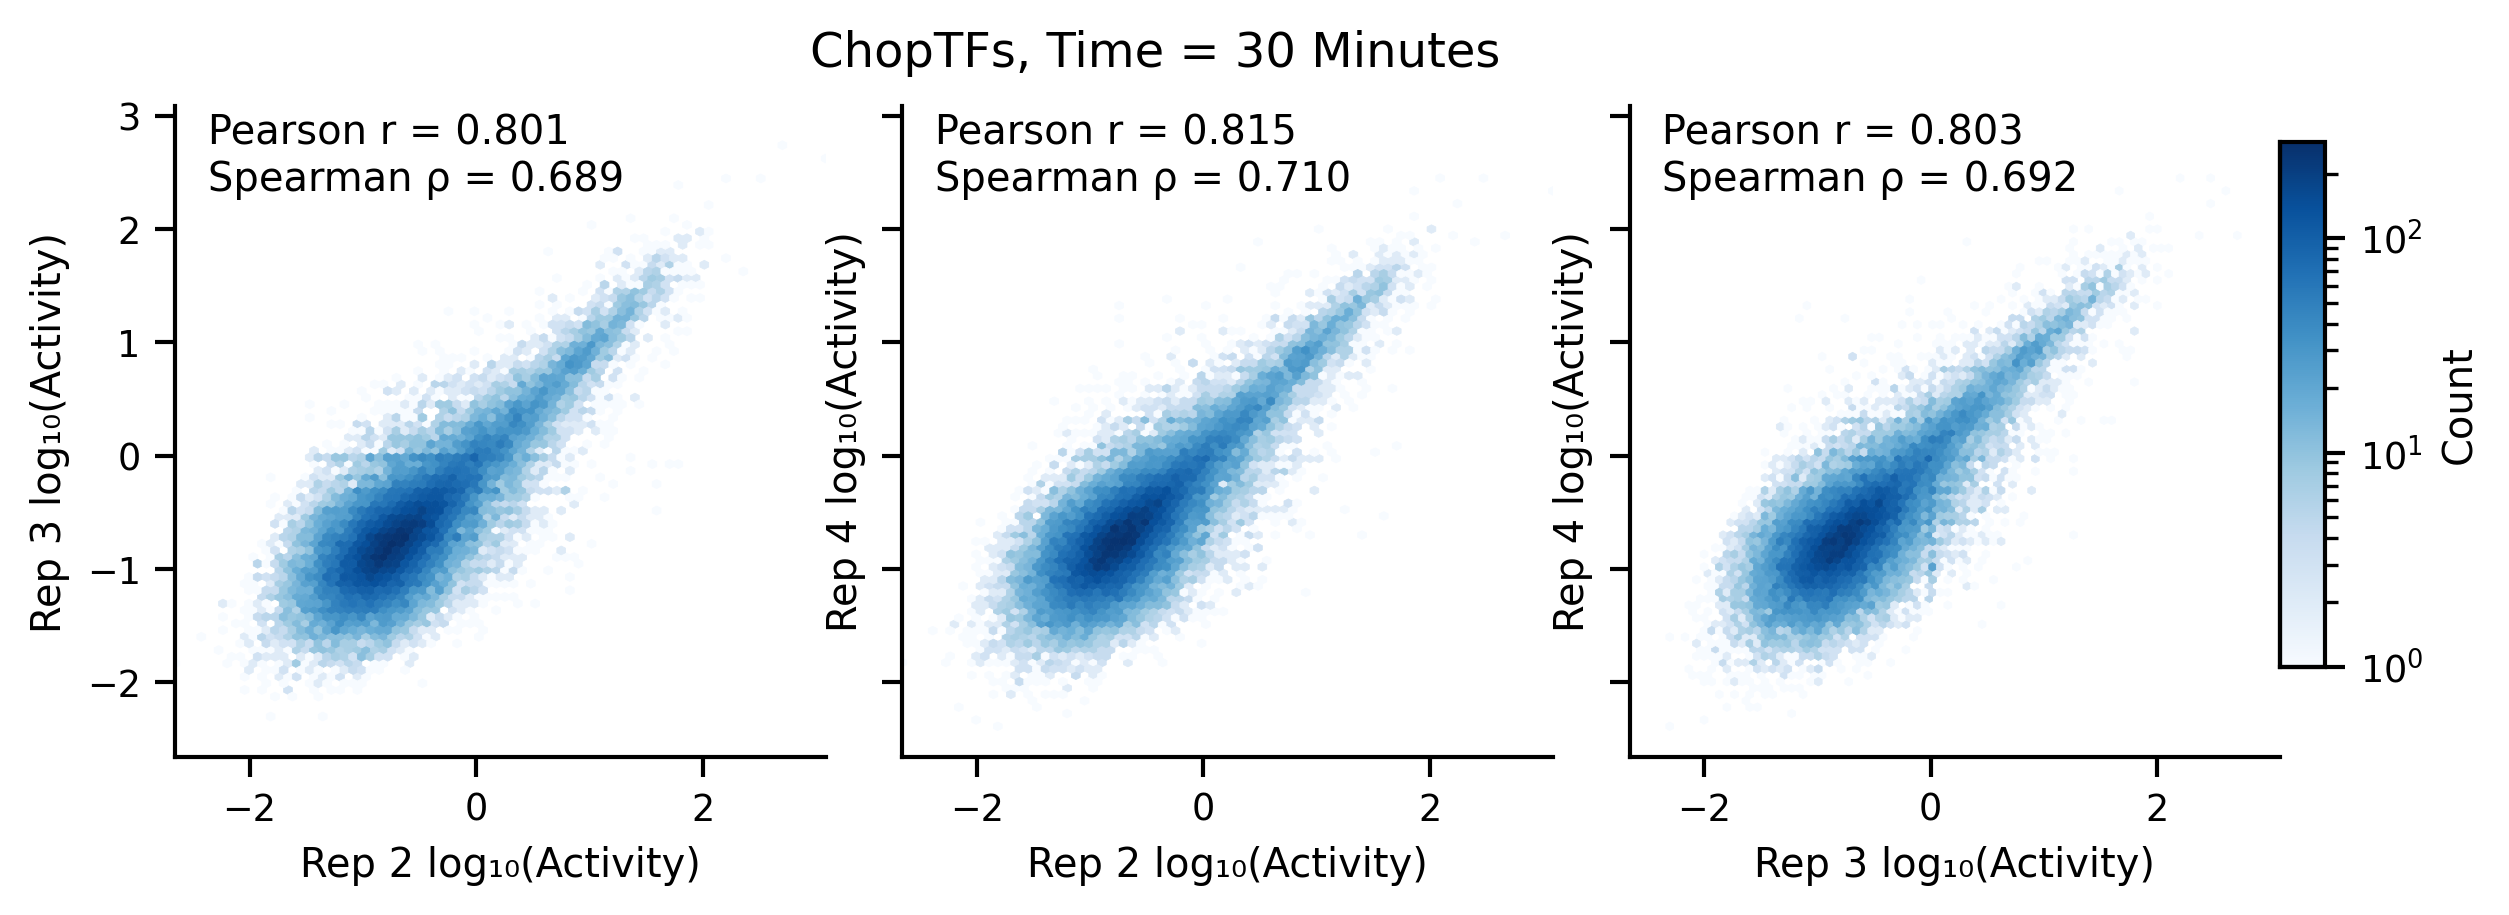

In [59]:
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_context('paper')
df30 = ChopTFs_t30

rep_pivot = (
    df30.pivot_table(
        index=["AD_BC", "RPTR_BC"],
        columns="rep",
        values="activity_directional",
        aggfunc="mean"
    )
    .dropna()
)

reps = sorted(rep_pivot.columns)
pairs = list(itertools.combinations(reps, 2))

fig, axes = plt.subplots(1, len(pairs), figsize=(2.5 * len(pairs), 2.5), dpi=300, sharex=True, sharey=True)
if len(pairs) == 1:
    axes = [axes]

all_counts = []
for r1, r2 in pairs:
    x, y = rep_pivot[r1], rep_pivot[r2]
    hb_tmp = fig.add_axes([0, 0, 0, 0])
    h = hb_tmp.hexbin(x, y, gridsize=75, mincnt=1)
    all_counts.append(h.get_array())
    hb_tmp.remove()

vmin = min(c.min() for c in all_counts)
vmax = max(c.max() for c in all_counts)
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

last_hb = None
for ax, (r1, r2) in zip(axes, pairs):
    x, y = rep_pivot[r1], rep_pivot[r2]
    pearson_r, _ = pearsonr(x, y)
    spearman_r, _ = spearmanr(x, y)

    last_hb = ax.hexbin(
        x, y,
        gridsize=75,
        cmap='Blues',
        norm=norm,
        linewidths=0.2,
        mincnt=1
    )

    lims = [
        min(rep_pivot.min().min(), rep_pivot.min().min()),
        max(rep_pivot.max().max(), rep_pivot.max().max())
    ]

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f"Rep {r1} log₁₀(Activity)")
    ax.set_ylabel(f"Rep {r2} log₁₀(Activity)")
    ax.text(
        0.05, 0.99,
        f"Pearson r = {pearson_r:.3f}\nSpearman ρ = {spearman_r:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize='medium',
    )

cax = fig.add_axes([1, 0.25, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(last_hb, cax=cax, label='Count')
sns.despine()
plt.tight_layout(pad = 0)

fig.suptitle("ChopTFs, Time = 30 Minutes", y = 1.1)
plt.savefig('../../output/paper_figs/S6_rep_correlation_hexbin_ChopTFs.png', dpi=300, bbox_inches='tight')
plt.savefig('../../output/paper_figs/S6_rep_correlation_hexbin_ChopTFs.pdf', bbox_inches='tight')
plt.show()

## GCN4

In [47]:
GCN4 = pd.read_csv("../../output/GCN4_pipeline/time_normalization/DBD_time_normalized_activities.csv", index_col = 0)
GCN4_t30 = GCN4[GCN4["time"] == 30]
GCN4_t30

,AD,AD_BC,RPTR_BC,rep,time,count_simple_AD,count_directional_AD,count_simple_RT,count_directional_RT,activity_simple,activity_directional,ADseq,dbd_overlap_flag,mu,sigma,z-scored_activity,shifted_activity,shifted_active,z-score_active
16306,GCTCCATCTGCTTCTCCAGCTCCATCTAGACAAGGTACTAAACATT...,TGCCGGAACAC,GATCTAAACTGATC,1,30,154,149,19,17,-2.092514,-2.170733,APSASPAPSRQGTKHSTVAGVNARQRKPLPPIKFDSADPA,False,-2.246740,0.700003,0.108581,0.076007,False,False
16307,GCTCCATTGTTTCCATCTAATGATGGTATGTCTATGCCATTTGATC...,AGCTGCGCTGG,ACCCAGCACGAGCT,1,30,154,143,63,49,-0.893818,-1.071024,APLFPSNDGMSMPFDPTSLEITAPVPAVKAEPPVSSPVVK,False,-2.246740,0.700003,1.679587,1.175715,False,False
16308,CCAATGTTTCCAGGTGATAATGAATTGGCTCCAGGTCATGAAGAAT...,ACAGCGCTGAA,TGGTGAGGAGGGAG,1,30,154,151,1365,1119,2.181957,2.002911,PMFPGDNELAPGHEEWESLFPVNDGFSSTNLDDLSAAVSA,False,-2.246740,0.700003,6.070906,4.249651,True,True
16309,AGGAAGATGTTGAGATTGACTGATTTGGAGAAACAAGTTGATGAAT...,TGCAACCGGTG,TACCGAACTATAAC,1,30,154,150,13,11,-2.472003,-2.612740,RKMLRLTDLEKQVDELTREHESALERIKELESEVTRLRGL,False,-2.246740,0.700003,-0.522856,-0.366000,False,False
16310,TTGAACTTTATGACTACTAATCAAATCTTGTCTGATAATGGTAGAT...,TTTATGCGCCC,GACCTCCTAGATTA,1,30,154,150,492,382,1.161526,0.934785,LNFMTTNQILSDNGRSKLSNLDTVELVIEAYNEFQSIHGF,False,-2.246740,0.700003,4.545018,3.181525,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178780,TCTATTGCTTCTAGATCTTCTTCTTCTTCTCCAAATAACTTTGCTC...,TCTAGATTCAC,TATTCGGCAGAGGA,3,30,3,3,5,4,0.510826,0.287682,SIASRSSSSSPNNFAPIDFTSFTTDYQPQTWLPSPPHPQP,False,-2.417606,0.702146,3.852883,2.705288,True,True
178781,ACTCATTTGCAACAAAGACAAACTAGACCACCAGTTCCACCATTCT...,GTATAGGTCGG,GAGCCAGTGAAAAA,3,30,1,1,3,3,1.098612,1.098612,THLQQRQTRPPVPPFSQSTGQIPQTPNMAMQDMDLFDEFT,False,-2.417606,0.702146,5.007813,3.516218,True,True
178782,ACTGCTACTATTCCATCTCATGACTTTCAATCATTTGTTACTGATC...,CCCTTCCACTA,CGGACGAATTAGTC,3,30,1,1,1,1,0.000000,0.000000,TATIPSHDFQSFVTDHHKRWLTQPQSPRLPPTTSNFHHDQ,False,-2.417606,0.702146,3.443165,2.417606,True,True
178783,TTCTCTCCATTGGATGGTTCTAAACCAACTAATGAATCTACTTCTG...,CTTGCCGGGCC,CAACCCACCTGCGT,3,30,1,1,11,8,2.397895,2.079442,FSPLDGSKPTNESTSASTTTAKPVVGQLVFDKFIKTEEDS,False,-2.417606,0.702146,6.404714,4.497047,True,True


/tmp/ipykernel_2163017/4227458060.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad = 0)


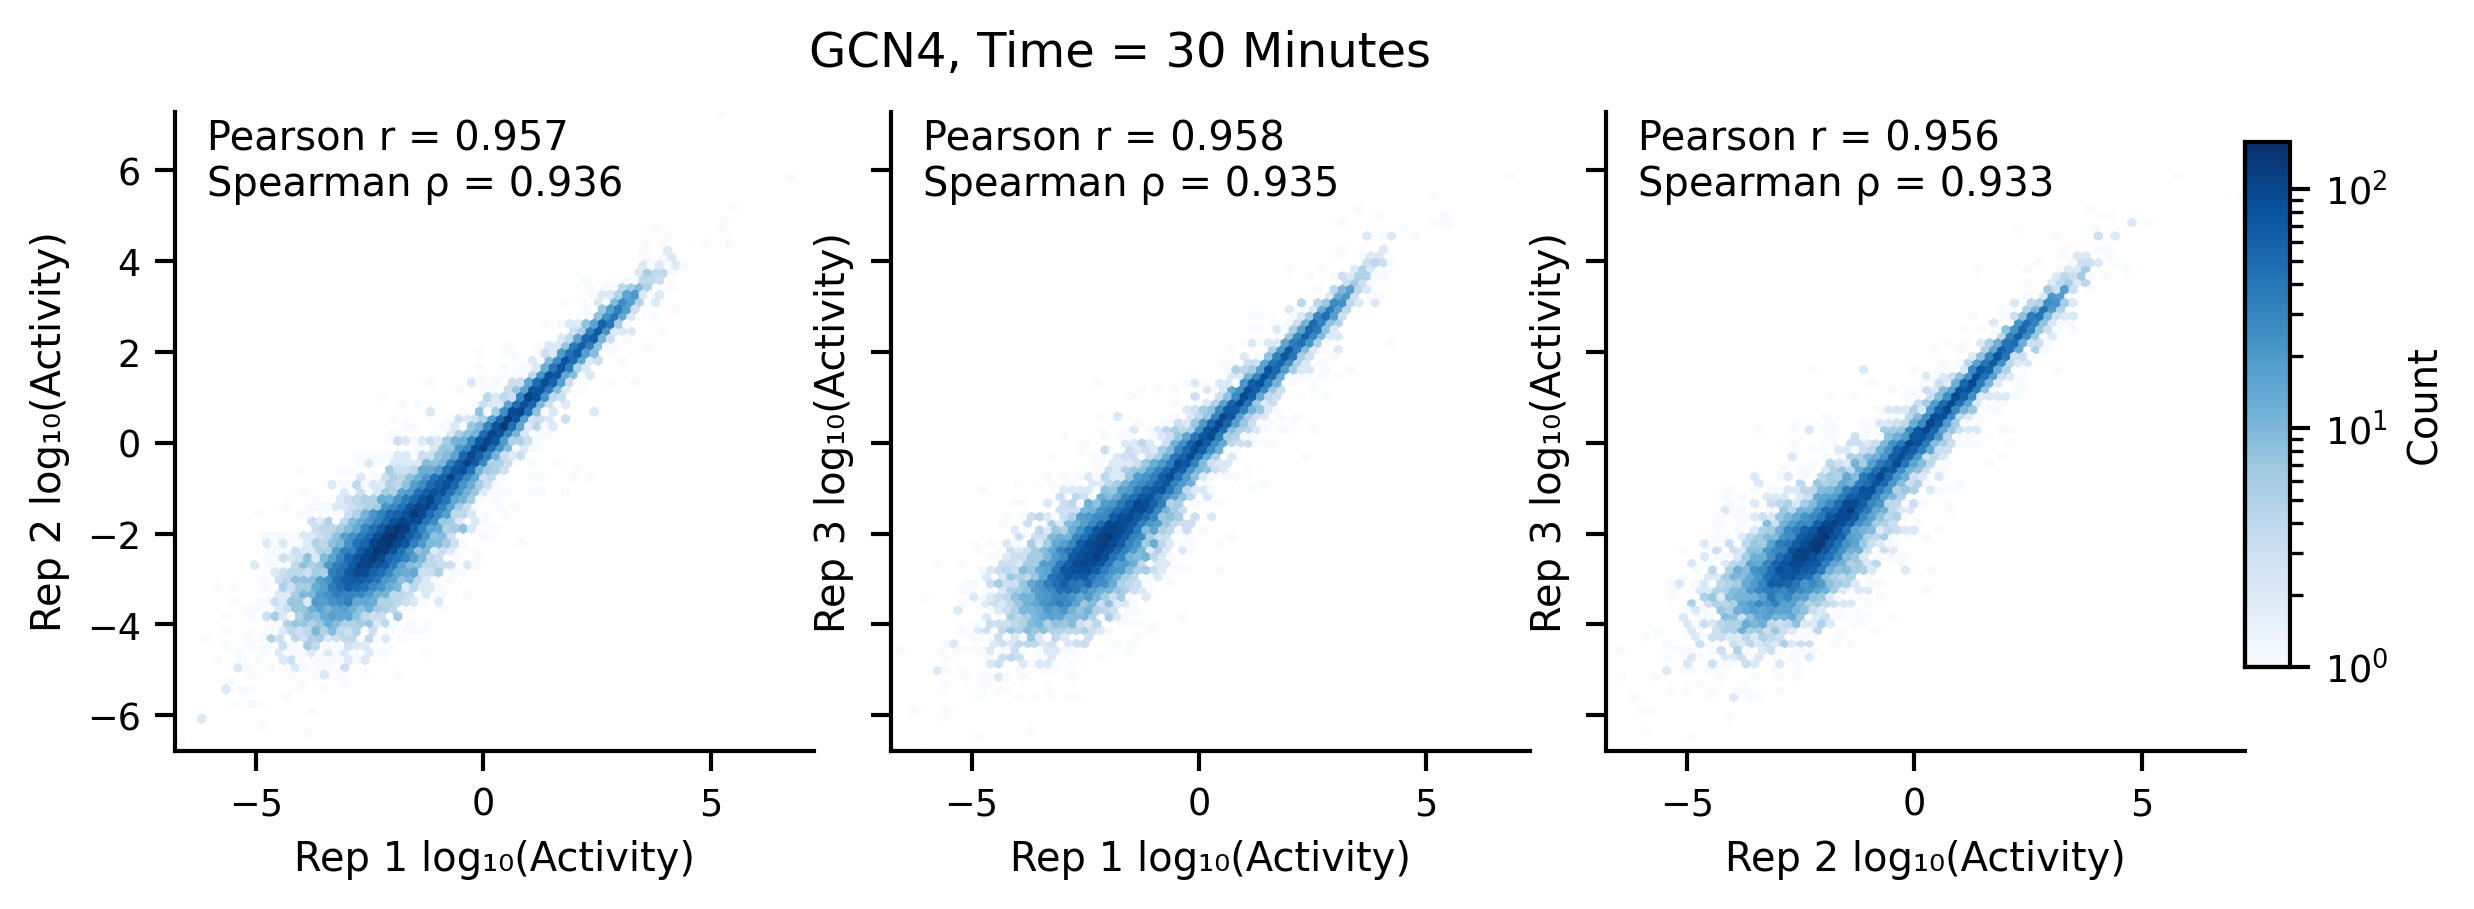

In [60]:
import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_context('paper')
df30 = GCN4_t30

rep_pivot = (
    df30.pivot_table(
        index=["AD_BC", "RPTR_BC"],
        columns="rep",
        values="activity_directional",
        aggfunc="mean"
    )
    .dropna()
)

reps = sorted(rep_pivot.columns)
pairs = list(itertools.combinations(reps, 2))

fig, axes = plt.subplots(1, len(pairs), figsize=(2.5 * len(pairs), 2.5), dpi=300, sharex=True, sharey=True)
if len(pairs) == 1:
    axes = [axes]

all_counts = []
for r1, r2 in pairs:
    x, y = rep_pivot[r1], rep_pivot[r2]
    hb_tmp = fig.add_axes([0, 0, 0, 0])
    h = hb_tmp.hexbin(x, y, gridsize=75, mincnt=1)
    all_counts.append(h.get_array())
    hb_tmp.remove()

vmin = min(c.min() for c in all_counts)
vmax = max(c.max() for c in all_counts)
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

last_hb = None
for ax, (r1, r2) in zip(axes, pairs):
    x, y = rep_pivot[r1], rep_pivot[r2]
    pearson_r, _ = pearsonr(x, y)
    spearman_r, _ = spearmanr(x, y)

    last_hb = ax.hexbin(
        x, y,
        gridsize=75,
        cmap='Blues',
        norm=norm,
        linewidths=0.2,
        mincnt=1
    )

    lims = [
        min(rep_pivot.min().min(), rep_pivot.min().min()),
        max(rep_pivot.max().max(), rep_pivot.max().max())
    ]

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    
    ax.set_xlabel(f"Rep {r1} log₁₀(Activity)")
    ax.set_ylabel(f"Rep {r2} log₁₀(Activity)")
    ax.text(
        0.05, 0.99,
        f"Pearson r = {pearson_r:.3f}\nSpearman ρ = {spearman_r:.3f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize='medium',
    )

cax = fig.add_axes([1, 0.25, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(last_hb, cax=cax, label='Count')
sns.despine()
plt.tight_layout(pad = 0)

fig.suptitle("GCN4, Time = 30 Minutes", y = 1.1)
plt.savefig('../../output/paper_figs/S6_rep_correlation_hexbin_GCN4.png', dpi=300, bbox_inches='tight')
plt.savefig('../../output/paper_figs/S6_rep_correlation_hexbin_GCN4.pdf', bbox_inches='tight')
plt.show()

## Both together

/tmp/ipykernel_2163017/3831791205.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


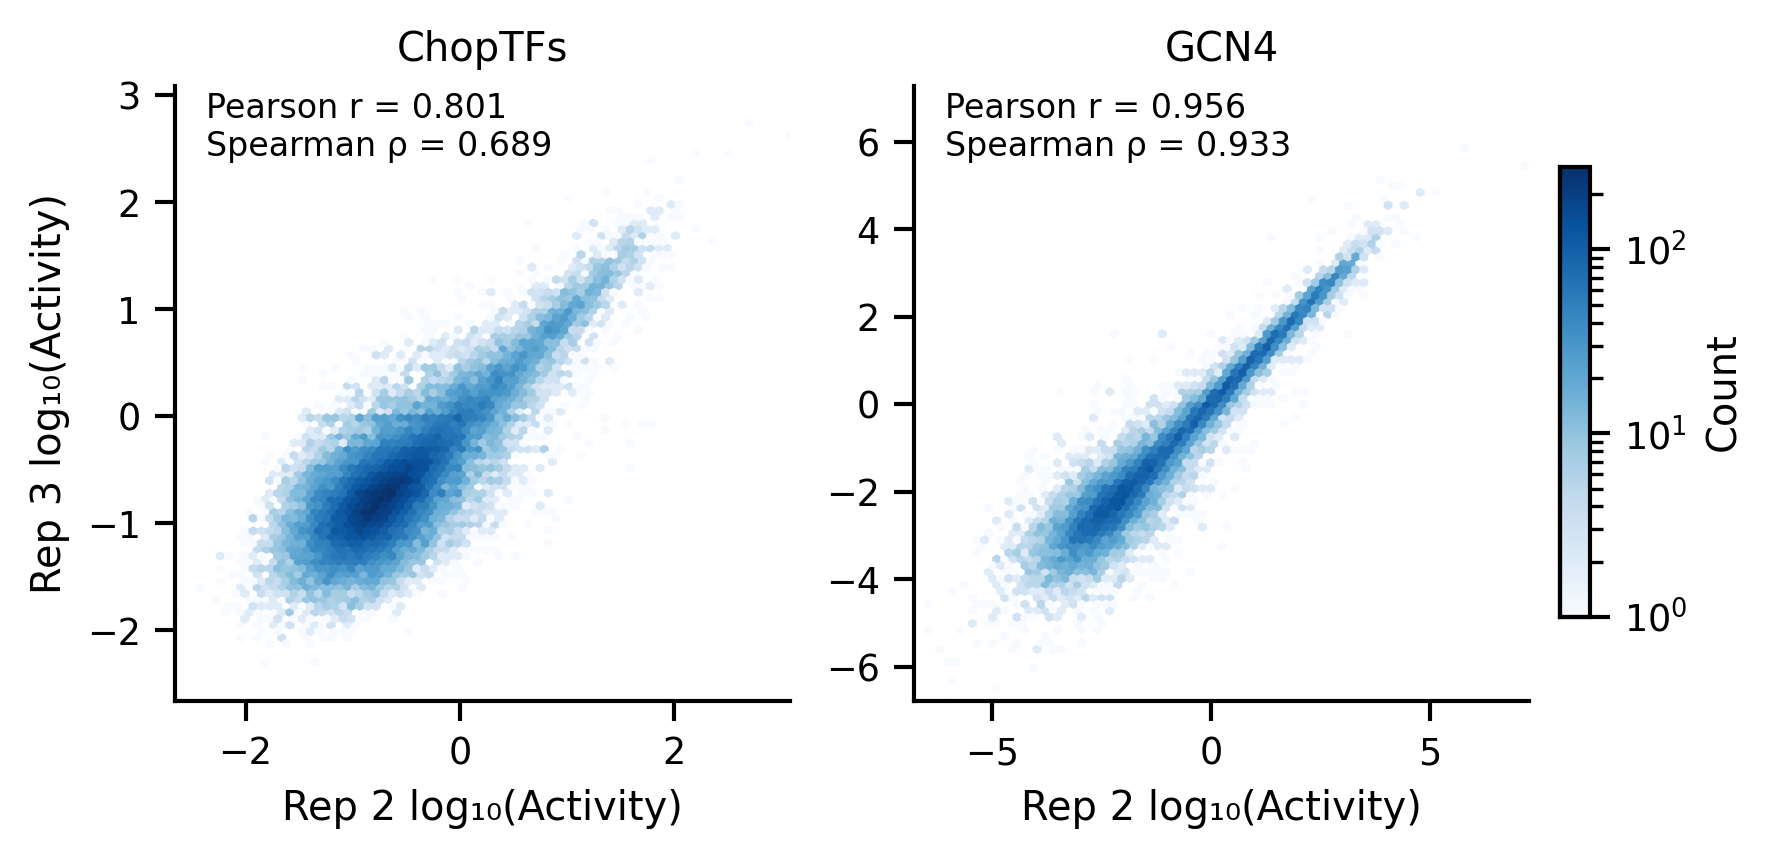

In [61]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

sns.set_context('paper')

datasets = [
    (ChopTFs_t30, "ChopTFs"),
    (GCN4_t30,    "GCN4"),
]

fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), dpi=300)

# --- collect counts for shared norm ---
all_counts = []
for df, _ in datasets:
    rep_pivot = (
        df.pivot_table(
            index=["AD_BC", "RPTR_BC"],
            columns="rep",
            values="activity_directional",
            aggfunc="mean"
        )
        .dropna()
    )
    x, y = rep_pivot[2], rep_pivot[3]
    hb_tmp = fig.add_axes([0, 0, 0, 0])
    h = hb_tmp.hexbin(x, y, gridsize=75, mincnt=1)
    all_counts.append(h.get_array())
    hb_tmp.remove()

norm = mcolors.LogNorm(
    vmin=min(c.min() for c in all_counts),
    vmax=max(c.max() for c in all_counts)
)

# --- plot ---
last_hb = None
for ax, (df, label) in zip(axes, datasets):
    rep_pivot = (
        df.pivot_table(
            index=["AD_BC", "RPTR_BC"],
            columns="rep",
            values="activity_directional",
            aggfunc="mean"
        )
        .dropna()
    )
    x, y = rep_pivot[2], rep_pivot[3]
    pearson_r, _  = pearsonr(x, y)
    spearman_r, _ = spearmanr(x, y)

    last_hb = ax.hexbin(x, y, gridsize=75, cmap='Blues', norm=norm,
                        linewidths=0.2, mincnt=1)

    lims = [
        min(rep_pivot.min().min(), rep_pivot.min().min()),
        max(rep_pivot.max().max(), rep_pivot.max().max())
    ]

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel("Rep 2 log₁₀(Activity)")
    ax.set_ylabel("Rep 3 log₁₀(Activity)")
    ax.set_title(label)
    ax.text(0.05, 0.99,
            f"Pearson r = {pearson_r:.3f}\nSpearman ρ = {spearman_r:.3f}",
            transform=ax.transAxes, ha="left", va="top", fontsize='small')

cax = fig.add_axes([1.02, 0.25, 0.02, 0.6])
fig.colorbar(last_hb, cax=cax, label='Count')

sns.despine()

axes[1].set_ylabel("")

plt.tight_layout(pad=0)

plt.savefig('../../output/paper_figs/S6_rep2v3_ChopTFs_GCN4.png', dpi=300, bbox_inches='tight')
plt.savefig('../../output/paper_figs/S6_rep2v3_ChopTFs_GCN4.pdf', bbox_inches='tight')
plt.show()

# also add your histogram comparing the two kinds of error

## Chop TFs

In [62]:
ChopTFs_tech_rep_err = ChopTFs_t30.groupby(["AD", "AD_BC", "RPTR_BC", "time"])["activity_directional"].agg(['mean', 'std', 'count']).reset_index()
ChopTFs_tech_rep_err["SE_tech"] = ChopTFs_tech_rep_err["std"] / np.sqrt(ChopTFs_tech_rep_err["count"])
ChopTFs_tech_rep_err["SE_tech_sq"] = ChopTFs_tech_rep_err["SE_tech"] ** 2
ChopTFs_tech_rep_err

,AD,AD_BC,RPTR_BC,time,mean,std,count,SE_tech,SE_tech_sq
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,ATAACCAATGG,TGAGAGAAAATCTA,30,-0.453755,0.094954,3,0.054822,0.003005
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TATCTTCGCTT,CCCTCACCCGATTA,30,-0.596527,0.143390,3,0.082786,0.006854
2,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,AATCGTACCGA,TTTGATATCCAAAC,30,-0.604442,0.129135,3,0.074556,0.005559
3,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,TTGCATAGCTG,TATTGTTCTCTGCT,30,-0.829397,0.072929,3,0.042106,0.001773
4,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,TTTATAATACC,CATCGAACCTGAAC,30,-0.822714,0.117628,3,0.067913,0.004612
...,...,...,...,...,...,...,...,...,...
54625,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,GAAAGGACAGA,CATATAGCTGGTAA,30,-0.367977,NaN,1,NaN,NaN
54626,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,GGGTCGTAAAT,CAACAGCCCTTACG,30,-0.698970,NaN,1,NaN,NaN
54627,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,TCTTCCTGAAT,TATGATAATGTGTA,30,-0.781464,0.554345,3,0.320051,0.102433
54628,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,GATCCCATGCA,CTCTGCTACTTGTG,30,-0.681905,0.051459,3,0.029710,0.000883


In [63]:
ChopTFs_bio_rep_err = ChopTFs_t30.groupby(["AD", 'rep', "time"])["activity_directional"].agg(['mean', 'std', 'count']).reset_index().dropna()
ChopTFs_bio_rep_err["SE_bio"] = ChopTFs_bio_rep_err["std"] / np.sqrt(ChopTFs_bio_rep_err["count"])
ChopTFs_bio_rep_err["SE_bio_sq"] = ChopTFs_bio_rep_err["SE_bio"] ** 2
ChopTFs_bio_rep_err

,AD,rep,time,mean,std,count,SE_bio,SE_bio_sq
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,2,30,-0.499943,0.184054,2,0.130145,0.016938
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,3,30,-0.498069,0.083065,2,0.058736,0.003450
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,4,30,-0.577411,0.201877,2,0.142748,0.020377
3,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,2,30,-0.818021,0.056027,3,0.032347,0.001046
4,AAAAATTCTAAGAGACAGAAATCTTCTACTTATACTTCTCAAACTT...,3,30,-0.702004,0.183348,3,0.105856,0.011206
...,...,...,...,...,...,...,...,...
47677,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,3,30,-1.039708,0.386188,3,0.222966,0.049714
47678,TTTGTTTCTTTGTTGGATACTCCATCTAAGAAATCTGATTCTAAAT...,4,30,-0.374716,0.015040,2,0.010635,0.000113
47679,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,2,30,-0.827825,0.234655,2,0.165926,0.027531
47680,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,3,30,-0.710802,0.095246,2,0.067349,0.004536


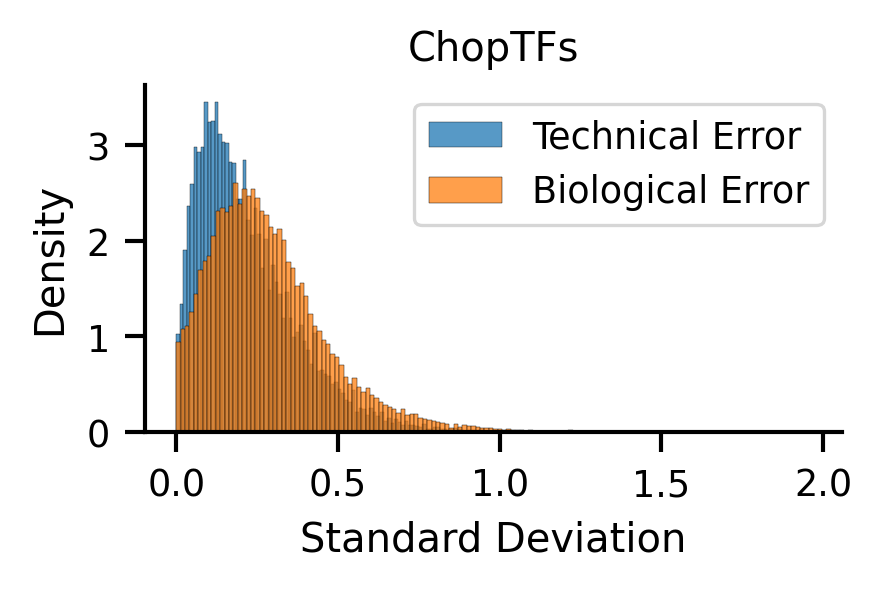

In [64]:
plt.figure(dpi = 300, figsize = (3,1.5))
sns.histplot(ChopTFs_tech_rep_err['std'], label = "Technical Error", fill = True, stat = 'density')
sns.histplot(ChopTFs_bio_rep_err['std'], label = "Biological Error", fill = True, stat = 'density')
plt.legend()
plt.title("ChopTFs")
plt.xlabel("Standard Deviation")
sns.despine()

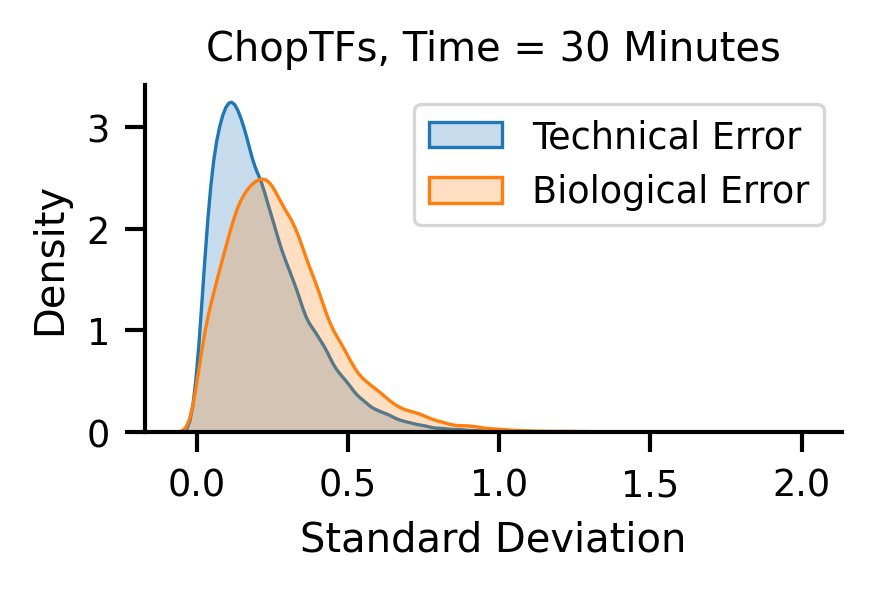

In [65]:
plt.figure(dpi = 300, figsize = (3,1.5))
sns.kdeplot(ChopTFs_tech_rep_err['std'], label = "Technical Error", fill = True)
sns.kdeplot(ChopTFs_bio_rep_err['std'], label = "Biological Error", fill = True)
plt.legend()
plt.title("ChopTFs, Time = 30 Minutes")
plt.xlabel("Standard Deviation")
sns.despine()

## GCN4

In [66]:
GCN4_tech_rep_err = GCN4_t30.groupby(["AD", "AD_BC", "RPTR_BC", "time"])["activity_directional"].agg(['mean', 'std', 'count']).reset_index()
GCN4_tech_rep_err["SE_tech"] = GCN4_tech_rep_err["std"] / np.sqrt(GCN4_tech_rep_err["count"])
GCN4_tech_rep_err["SE_tech_sq"] = GCN4_tech_rep_err["SE_tech"] ** 2
GCN4_tech_rep_err

,AD,AD_BC,RPTR_BC,time,mean,std,count,SE_tech,SE_tech_sq
0,AAACAAAGAGCTACTCCATTGACTCCAGTTGTTCCAGAATCTGATG...,ACCCCTCGCCG,AGTTCATGCTCCGA,30,-1.959865,0.452989,3,0.261533,0.068400
1,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,AACGAACCTTT,TCAGCTTGCTAATA,30,-3.538714,0.292293,3,0.168755,0.028478
2,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TACATGCAATG,CAAGTGTCGGTGCT,30,-1.637525,0.259679,3,0.149926,0.022478
3,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,TCCGATGATCA,TATTCATAGTCTCA,30,-1.344974,0.169373,3,0.097788,0.009562
4,AAACAAATGTATATTGGTTCTAATAAACCATTGGGTAAAGATCATA...,TCCCACCTCCC,CGCCAGTTCACGCA,30,-2.812134,0.056773,3,0.032778,0.001074
...,...,...,...,...,...,...,...,...,...
16737,TTTGTTGCTTCTCCAACATTTAATCATAAATTCTCTTCTTCTAATG...,TTGCCTGCACT,ATATGGAAATATGA,30,1.846423,0.057782,3,0.033360,0.001113
16738,TTTGTTGGTGATGGTGATTTGGATCAATCTTTGGCTGCTGATCCAT...,ATCAAGCAAGG,TAGACCCGGAGAGG,30,1.224578,0.153905,3,0.088857,0.007896
16739,TTTGTTGTTTCTAGATCTCCAGCTGCTGTTCATATTGCTTGTTGTA...,CGAATCAAATG,ATAAACATTAGAAG,30,-3.061813,0.845788,3,0.488316,0.238453
16740,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,AATTGAGCGAT,GTCAAGATACCTCG,30,0.326219,0.037559,3,0.021685,0.000470


In [67]:
GCN4_bio_rep_err = GCN4_t30.groupby(["AD", 'rep', "time"])["activity_directional"].agg(['mean', 'std', 'count']).reset_index().dropna()
GCN4_bio_rep_err["SE_bio"] = GCN4_bio_rep_err["std"] / np.sqrt(GCN4_bio_rep_err["count"])
GCN4_bio_rep_err["SE_bio_sq"] = GCN4_bio_rep_err["SE_bio"] ** 2
GCN4_bio_rep_err

,AD,rep,time,mean,std,count,SE_bio,SE_bio_sq
3,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,1,30,-1.981812,1.102113,3,0.636305,0.404885
4,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,2,30,-2.340201,1.337014,3,0.771925,0.595869
5,AAACAAAGATCTCAACCATTGCAACCAATTATTATTGATGATATTA...,3,30,-2.199200,1.156637,3,0.667785,0.445936
9,AAACAACCAGATGTTGCTACTTGGGATGCTCATTCTAATAAAGGTC...,1,30,-2.396737,0.282153,2,0.199512,0.039805
10,AAACAACCAGATGTTGCTACTTGGGATGCTCATTCTAATAAAGGTC...,2,30,-1.996761,1.436745,2,1.015932,1.032117
...,...,...,...,...,...,...,...,...
32676,TTTGTTATTGGTTCTCAAATTGCTGGTCATGAGAAGATCTTGCAAG...,2,30,-3.505302,0.120402,2,0.085137,0.007248
32677,TTTGTTATTGGTTCTCAAATTGCTGGTCATGAGAAGATCTTGCAAG...,3,30,-3.521531,0.236666,2,0.167348,0.028005
32699,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,1,30,0.321701,0.003850,2,0.002722,0.000007
32700,TTTGTTTCTGGTACTGTTTCTCCTAAAGATTTGCATGTTGATACTG...,2,30,0.315671,0.069257,2,0.048972,0.002398


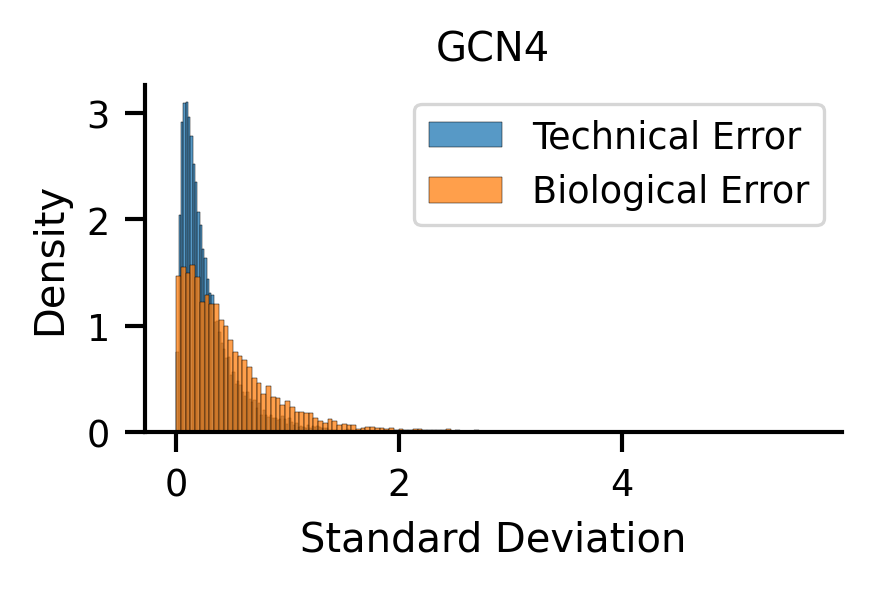

In [68]:
plt.figure(dpi = 300, figsize = (3,1.5))
sns.histplot(GCN4_tech_rep_err['std'], label = "Technical Error", fill = True, stat = 'density')
sns.histplot(GCN4_bio_rep_err['std'], label = "Biological Error", fill = True, stat = 'density')
plt.legend()
plt.title("GCN4")
plt.xlabel("Standard Deviation")
sns.despine()

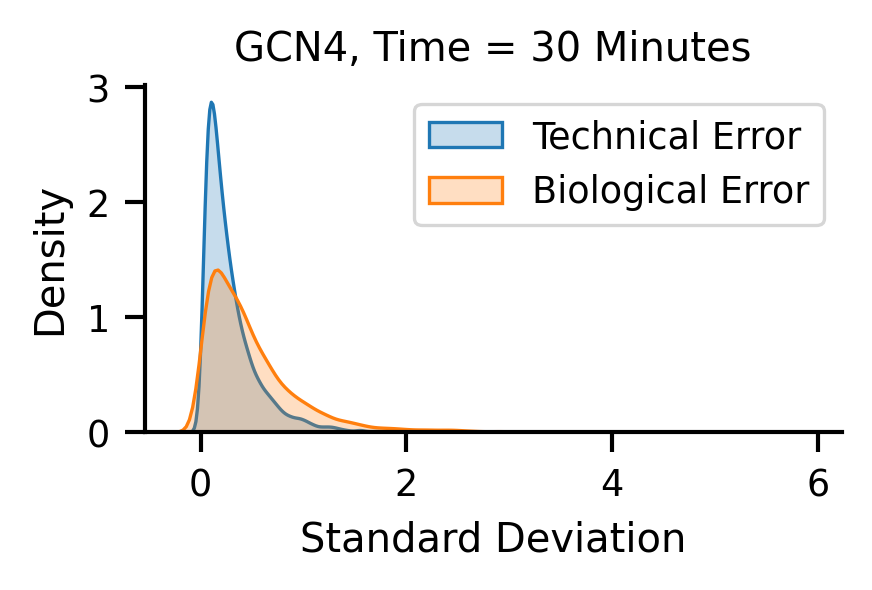

In [69]:
plt.figure(dpi = 300, figsize = (3,1.5))
sns.kdeplot(GCN4_tech_rep_err['std'], label = "Technical Error", fill = True)
sns.kdeplot(GCN4_bio_rep_err['std'], label = "Biological Error", fill = True)
plt.legend()
plt.title("GCN4, Time = 30 Minutes")
plt.xlabel("Standard Deviation")
sns.despine()

## Both together

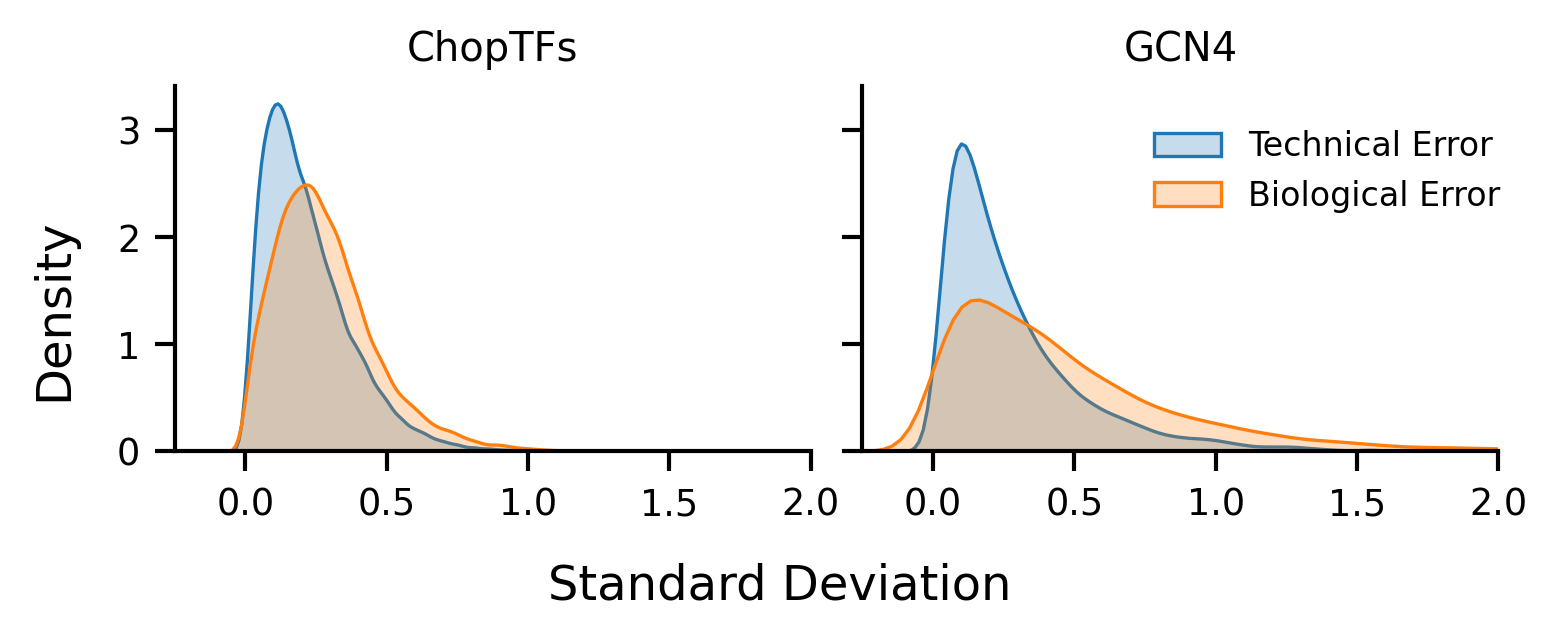

In [72]:
fig,axs = plt.subplots(1,2, figsize = (5,2), sharex = True, sharey = True, dpi = 300)

sns.kdeplot(ChopTFs_tech_rep_err['std'], label = "Technical Error", fill = True, ax = axs[0])
sns.kdeplot(ChopTFs_bio_rep_err['std'], label = "Biological Error", fill = True, ax = axs[0])
axs[0].set_title("ChopTFs")

sns.kdeplot(GCN4_tech_rep_err['std'], label = "Technical Error", fill = True, ax = axs[1])
sns.kdeplot(GCN4_bio_rep_err['std'], label = "Biological Error", fill = True, ax = axs[1])
axs[1].set_title("GCN4")

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supylabel("Density", x = 0)
fig.supxlabel("Standard Deviation", y = 0)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1, 0.85), fontsize='small', frameon=False)

axs[0].set_xlim(-0.25,2)
plt.tight_layout(pad = 0.5)
sns.despine()
plt.savefig('../../output/paper_figs/S6_tech_vs_bio_err_hists.png', dpi=300, bbox_inches='tight')
plt.savefig('../../output/paper_figs/S6_tech_vs_bio_err_hists.pdf', bbox_inches='tight')
